# Exercise 14: Mediation

This homework assignment is designed to give you practice with mediation. You won't need to load in any data for this homework -- we'll simulate data instead.

---
## 1. Simulating data (3 points)


In this homework, we're going to simulate the relationship between age, word reading experience, and reading comprehension skill. Older children tend to be better at reading comprehension tasks, but this isn't just an inherent part of getting older. It's a combination of gaining more experience with reading, oral language skills, and executive functions development. In this homework, though, we're going to simplify this relationship down to a direct effect of age on reading comprehension (since improvements in oral language skills and executive functions are more guaranteed as children age than reading practice is), and a mediation of word reading experience.

In graphical form:
![picture](https://drive.google.com/uc?id=1wdm9xuiJhBJor99-9GnicO2_rzkGWtfN)

Writing the relationship out formally:

$$x = \beta_{xa} a + \beta_{x0} + \epsilon_{x}$$

$$c = \beta_{ca} a + \beta_{cx} x + \beta_{c0} + \epsilon_c$$



$c$ is reading comprehension, $x$ is word reading experience, and $a$ is age. $\beta_{c0}$ and $\beta_{x0}$ are intercept terms for their respective formulas, and $\epsilon_{c}$ and $\epsilon_{x}$ are gaussian noise terms. We'll start by writing a function, `simulate_data`, that can simulate this relationship. The input values are set and the function structure is provided below. Complete the function such that it takes in those input variables and generates $age$, $x$, and $c$ values. Use `runif()` to generate ages. Use `rnorm()` to generate the noise terms.

In [15]:
sample_size = 100 # How many children in data set?
age_lo = 80     # minimum age, in months
age_hi = 200    # maximum age, in months
beta_xa = 0.5   # amount by which experience changes for increase of one month in age
beta_x0 = -5    # amount of experience when age = 0 (not interpretable, since minimum age for this data is 80 months)
sd_x = 50       # standard dev of gaussian noise term, epsilon_x
beta_ca = 0.8   # amount that comprehension score improves for every increase of one unit in age
beta_cx = 3     # amount that comprehension score improves for every increase of one unit in reading experience
beta_c0 = 10    # comprehension score when reading experience is 0.
sd_c = 85      # standard dev of gaussian noise term, epsilon_c

simulate_data <- function(sample_size, age_lo, age_hi, beta_xa, 
                          beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c) {
      # WRITE YOUR CODE HERE
      # simulated data contains 3 values, age, implement the two equations - x, and c.
      # runif(sample size, age_lo, age_hi)
      age = runif(sample_size, age_lo, age_hi)
      x = beta_xa*age + beta_x0 + rnorm(sample_size, 0, sd_x)
      c = beta_ca*age + beta_cx*x + beta_c0 + rnorm(sample_size, 0, sd_c)
      return(data.frame(age=age,x=x,c=c))
}     

dat <- simulate_data(sample_size, age_lo, age_hi, beta_xa, beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c)
str(dat)

'data.frame':	100 obs. of  3 variables:
 $ age: num  141 149 196 190 133 ...
 $ x  : num  96.3 45 65.8 118.8 138.9 ...
 $ c  : num  378 166 349 644 309 ...


---
## 2. Visualizing Data (2 point)

Load the `tidyverse` library.

In [16]:
library(tidyverse)

a) Create a scatter plot showing the relationship between age and reading comprehension.

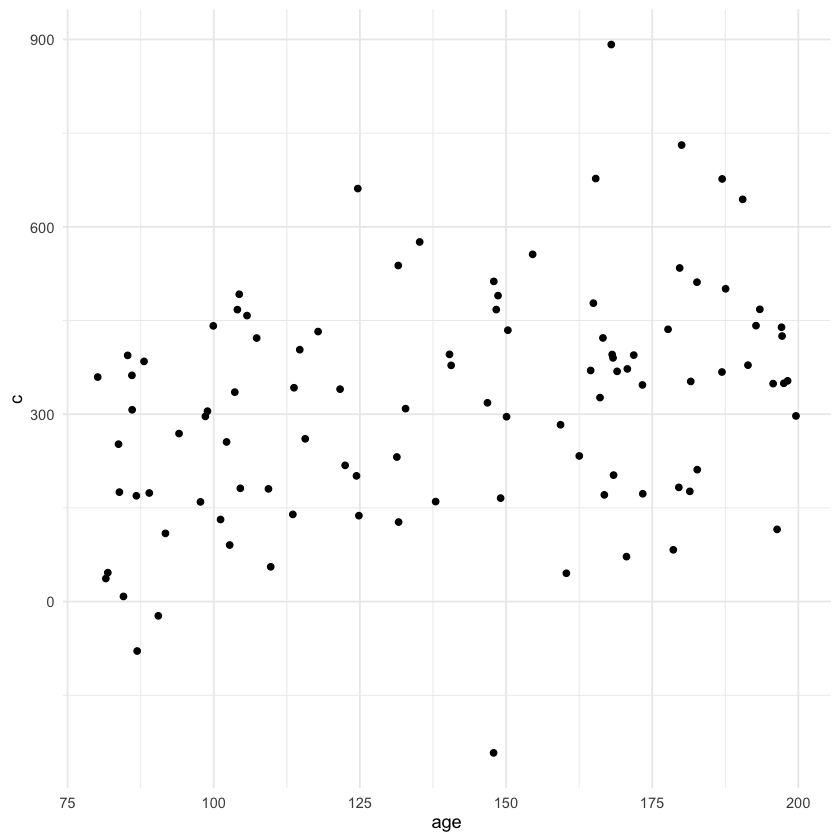

In [17]:
ggplot(dat, aes(x = age, y = c)) +
geom_point() +
theme_minimal()

b) Create a scatter plot showing the relationship among age, reading experience, and reading comprehension.

*Hint: You can represent reading comprehension using an additional visual dimension such as the color or size of the points.*

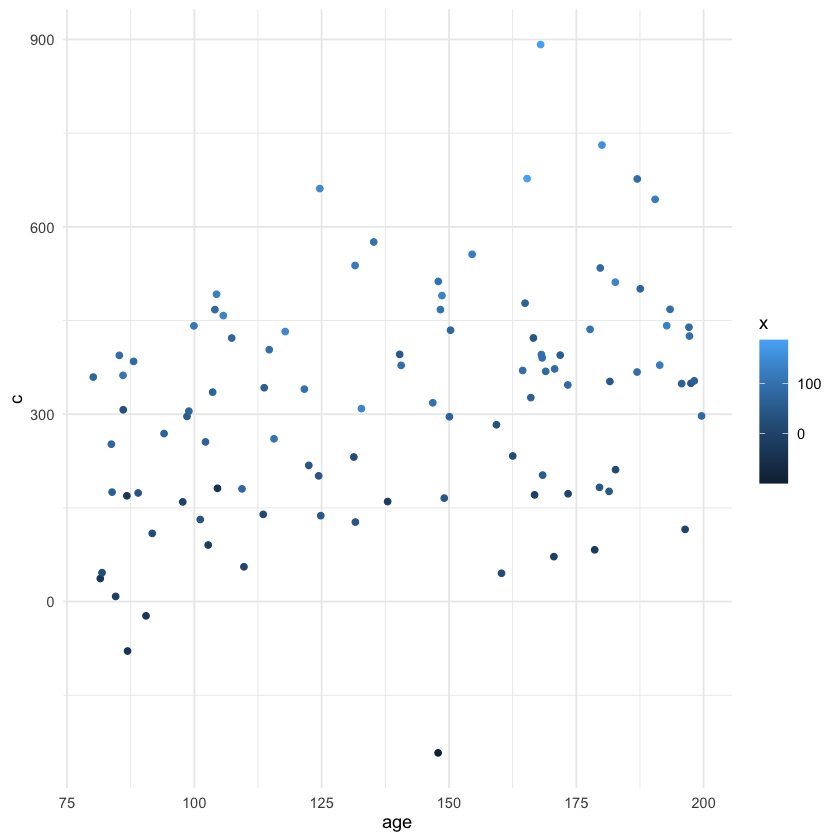

In [18]:
ggplot(dat, aes(x = age, y = c, color = x)) +
geom_point() +
theme_minimal()

---
## 3. Mediation Analysis (4 points)

Load the `mediation` library.

In [19]:
install.packages("mediation")
library(mediation)


The downloaded binary packages are in
	/var/folders/5_/v0q2657s7b354r1303qrlrxw0000gp/T//RtmpB9PCVZ/downloaded_packages


Use the `mediate` function to determine whether `x` mediates the relationship between `age` and `c`. Use `summary()` to print the model results. *Hint: see the mediation and moderation tutorial.*

In [20]:
mod_1 <- lm(x ~ age, data = dat)
summary(mod_1)

mod_2 <- lm(c ~ age + x, data = dat)
summary(mod_2)

med_mod <- mediate(mod_1, mod_2, treat = "age", mediator = "x")
summary(med_mod)


Call:
lm(formula = x ~ age, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-166.369  -29.637    9.981   32.724  115.160 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  22.0728    20.0200   1.103   0.2729  
age           0.3020     0.1375   2.196   0.0304 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 51.83 on 98 degrees of freedom
Multiple R-squared:  0.04691,	Adjusted R-squared:  0.03719 
F-statistic: 4.824 on 1 and 98 DF,  p-value: 0.03042



Call:
lm(formula = c ~ age + x, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-216.06  -59.22  -13.80   53.02  242.07 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  20.3072    35.2151   0.577  0.56550    
age           0.7883     0.2463   3.201  0.00185 ** 
x             2.8802     0.1766  16.310  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 90.61 on 97 degrees of freedom
Multiple R-squared:  0.7638,	Adjusted R-squared:  0.7589 
F-statistic: 156.8 on 2 and 97 DF,  p-value: < 2.2e-16



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value    
ACME            0.86516      0.10639      1.68377   0.016 *  
ADE             0.78613      0.28038      1.26964  <2e-16 ***
Total Effect    1.65129      0.75776      2.53770  <2e-16 ***
Prop. Mediated  0.51659      0.13029      0.77640   0.016 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Sample Size Used: 100 


Simulations: 1000 


---
## 5. Reflection (1 point)
Is there a significant direct or indirect effect? What do you conclude based on the analyses above?

> I think the results indicate a significant indirect effect of age on reading comprehension via reading experience. This suggests that reading experience functions as a mediator. In addition, the direct effect of age on reading comprehension remains significant after controlling for reading experience.

> Altogether, these findings suggest that reading experience is a partial mediator of the relationship between age and reading comprehension. This means that while some of the effect of age on reading comprehension operates through reading experience, I think there is still a significant direct effect, indicating that other factors may also contribute to this relationship, such as family SES or the number of languages spoken at home.

**DUE:** 11:59pm EST, March 26, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment.